# EXPLORATORY DATA ANALYSIS OF NETFLIX MOVIES WITH PYTHON

In [493]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"C:\Users\kanha\OneDrive\Documents\jyupitter\mymoviedb.csv",lineterminator='\n')

In [495]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [496]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
        9837 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [497]:
print(df.columns)

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url\r'],
      dtype='str')


In [498]:
print(df['Vote_Count'].unique()[:20])

<StringArray>
['8940', '1151',  '122', '5076', '1793',   '33',  '821',  '206',  '114',
 '4726',   '16',  '100',  '107',  '952',  '737',  '288',  '521',   '65',
   '31', '3193']
Length: 20, dtype: str


In [499]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Count'] = df['Vote_Count'].astype('Int64')

print(df['Vote_Count'].dtype)

Int64


In [500]:
df['Vote_Average']=pd.to_numeric(df['Vote_Average'],errors='coerce')
df['Vote_Count'] = df['Vote_Count'].astype('float64')
print(df['Vote_Count'].dtype)


float64


In [501]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9826 non-null   float64
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
        9837 non-null   str    
dtypes: float64(3), str(6)
memory usage: 691.8 KB


In [502]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [503]:
df.duplicated().sum()

np.int64(0)

In [504]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9826.000000,9826.000000
mean,40.320570,1392.943721,6.439467
std,108.874308,2611.303856,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,444.000000,6.500000
75%,35.174500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [505]:
df.isnull().sum()


Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           11
Vote_Average         11
Original_Language    10
Genre                11
Poster_Url\r          0
dtype: int64

### EXPLORATION SUMMARY :

1. we have a dataframe consisting of 9827 rows and 9 col.
2. our dataset looks a bit tidy with no NaNs nor dublicated values.
3. data type of vote_count and vote_average.
4. col needs to be casted into date time and to extract only year values.
5. Original_Language and Poster-url would not to be so useful during analysis,so we will drop them.
6. Average better be categorized for proper analysis.
7. col has comma seperated values and white spaces that needs to be handled and casted into category.

In [506]:
df=df.dropna()

In [507]:
df['Release_Date']=pd.to_datetime(df['Release_Date'],errors='coerce',dayfirst=True)
print(df['Release_Date'].dtypes)

datetime64[us]


In [508]:
df['Release_Date']=df['Release_Date'].dt.year
df['Release_Date'].dtype

dtype('int32')

In [509]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [510]:
df['Release_Date'] = df['Release_Date'].astype('Int64')
df['Release_Date'].dtype


Int64Dtype()

In [511]:
cols=['Overview','Original_Language','Poster_Url\r']
df.drop(cols,axis=1,inplace=True)

In [512]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,6.3,Thriller
3,2021,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"


categorizing Vote_Average column
We would cut the Vote_Average values and make 4 categories popular,avg,below_avg,not_popular to describe it more using categgorize_col() function

In [513]:
def categorize_col(df,col,labels): 
            edges=[df[col].describe()['min'],
                   df[col].describe()['25%'],
                   df[col].describe()['50%'],
                   df[col].describe()['75%'],
                   df[col].describe()['max']]
            df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
            return df
                   


In [514]:
labels=['not_popolar','below_avg','average','popular']
categorize_col( df,'Vote_Average',labels)
df['Vote_Average'].unique()


['popular', 'below_avg', 'average', 'not_popolar', NaN]
Categories (4, str): ['not_popolar' < 'below_avg' < 'average' < 'popular']

In [515]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,below_avg,Thriller
3,2021,Encanto,2402.201,5076.0,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,average,"Action, Adventure, Thriller, War"


In [516]:
df['Vote_Average'].value_counts()

Vote_Average
not_popolar    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

#we would split genres into a list and then explode our dataframe to have only one genre per row for each movie...
eg.spider-man-Action
   spider-man-Adventure..
   

In [517]:
df['Genre']=df['Genre'].str.split(', ')
df=df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,Crime
4,2022,The Batman,3827.658,1151.0,popular,Mystery


In [518]:
#how many movies belong to each genre and which genre appears the most in the dataset.
#the number of movies released in each genre every year

In [519]:

df['Genre'].value_counts()


Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: count, dtype: int64

In [520]:
df.groupby(['Release_Date','Genre']).size()

Release_Date  Genre          
1902          Adventure          1
              Fantasy            1
              Science Fiction    1
1920          Crime              1
              Drama              1
                                ..
2023          Science Fiction    5
2024          Adventure          1
              Animation          1
              Comedy             1
              Family             1
Length: 1403, dtype: int64

### INSIGHTS:
1. Drama genre has the highest number of movies (3744), making it the most common genre in the dataset.
2. Comedy is the second most frequent genre with 3031 movies.
3. Action and Thriller are also highly represented genres.
4. In recent years, Science Fiction became more popular.
5. Older genres like Western became less common over time.


In [521]:
#casting column into category
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [522]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  Int64   
 1   Title         25792 non-null  str     
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  float64 
 4   Vote_Average  25551 non-null  category
 5   Genre         25792 non-null  category
dtypes: Int64(1), category(2), float64(2), str(1)
memory usage: 882.0 KB


In [523]:
df.nunique()

Release_Date     102
Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

### DATA VISUALIZATION

#What is most frequent genre of movies released on Netflix?


In [524]:
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

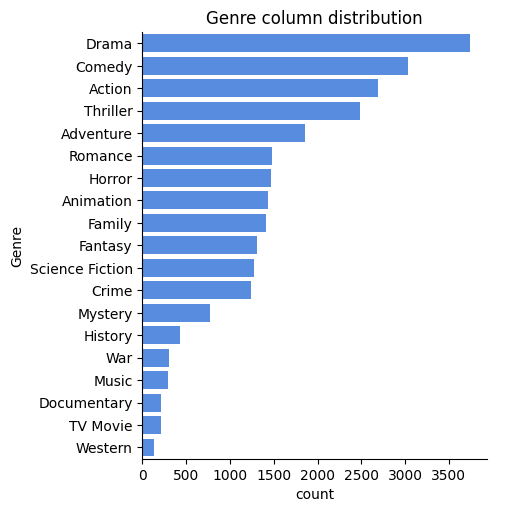

In [525]:
sns.catplot(y='Genre',data=df,kind='count',
            order=df['Genre'].value_counts().index,
            color='#4287f5')
plt.title('Genre column distribution')
plt.show()

#which has highest vote in vote avg column?

In [526]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,Crime
4,2022,The Batman,3827.658,1151.0,popular,Mystery


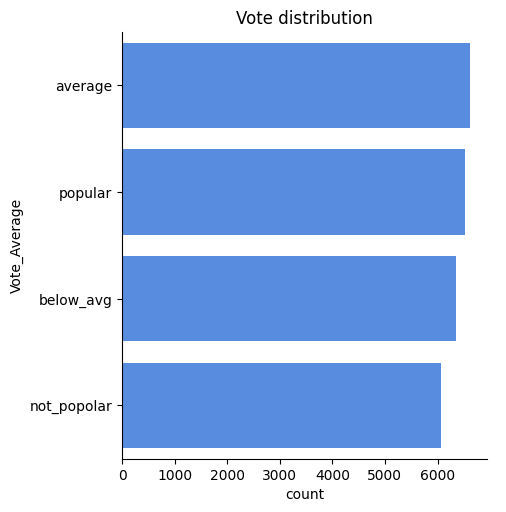

In [527]:
sns.catplot(y='Vote_Average',data=df,kind='count',
            order=df['Vote_Average'].value_counts().index,
            color='#4287f5'
            )
plt.title('Vote distribution')
plt.show()

#what movie got the highest popularity? what's its genre?

In [528]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction


#what movie got the lowest popularity? what's its genre?

In [529]:
df['Release_Date'].isna().sum()

np.int64(0)

In [530]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152.0,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152.0,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152.0,average,History
25789,1984,Threads,13.354,186.0,popular,War
25790,1984,Threads,13.354,186.0,popular,Drama
25791,1984,Threads,13.354,186.0,popular,Science Fiction


#which year has the most filmmed movies?

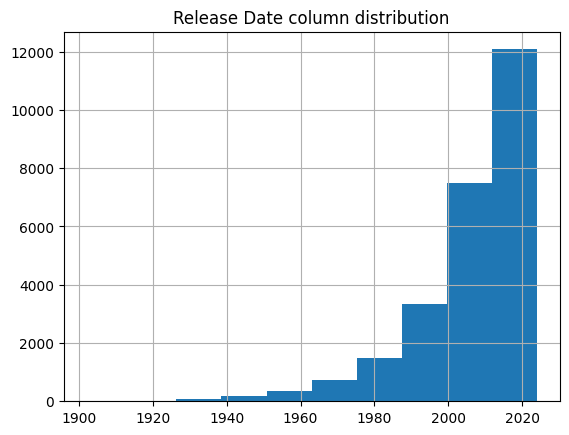

In [531]:
df['Release_Date'].hist()
plt.title('Release Date column distribution')
plt.show()

# Conclusion

Q1: What is the most frequent genre in the dataset?
Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among all genres.

Q2: Which genre has highest votes?
About 25.5% of the dataset has popular votes (6520 rows). Drama again gets the highest popularity among fans, having more than 18.5%.

Q3: What movie got the highest popularity? What is its genre?
Spider-Man: No Way Home has the highest popularity rate in our dataset and its genres are Action, Adventure and Science Fiction.

Q4: What movie got the lowest popularity? What's its genre?
The United States, Thread has the lowest popularity rate in our dataset and its genres are Music, Drama, War, Sci-Fi and History.

Q5: Which year has the most filmed movies?
Year 2020 has the highest filming rate in our dataset.